# Controlling figure aesthetics

📄 Source: https://seaborn.pydata.org/tutorial/aesthetics.html

Attractive figures matter, for exploring and even more for communicating to an audience. Matplotlib is very customisable, but it's hard to know which settings to change. Seaborn provides **themes** and a high-level interface to control the look of matplotlib figures.

🔗 The result of this notebook goes into `plotting_utils.py` (see the end).

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(sum(map(ord, "aesthetics")))
print("seaborn", sns.__version__)

seaborn 0.13.2


A helper that plots some offset sine waves, so we can see the style parameters change:

In [2]:
def sinplot(n=10, flip=1):
    x = np.linspace(0, 14, 100)
    for i in range(1, n + 1):
        plt.plot(x, np.sin(x + i * .5) * (n + 2 - i) * flip)   # pyplot -> draws on the current Axes

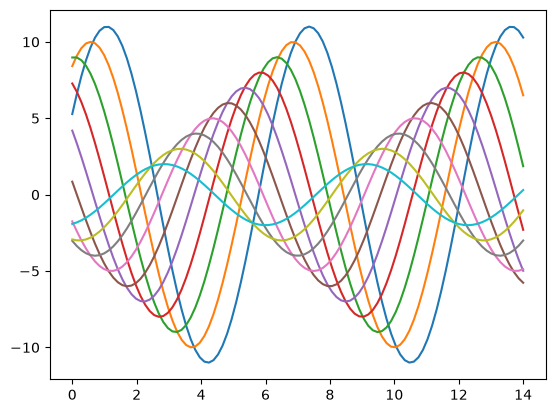

In [3]:
# Matplotlib defaults
sinplot()

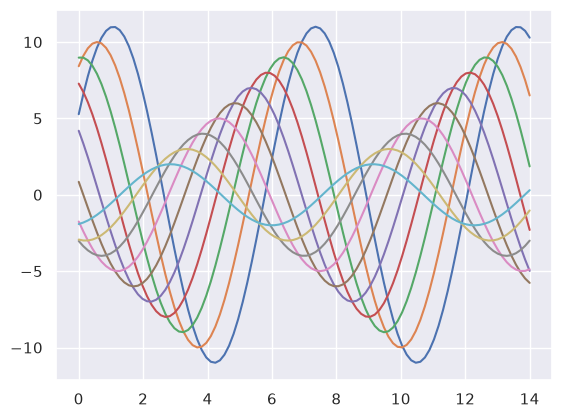

In [4]:
# Seaborn defaults: call set_theme()
sns.set_theme()
sinplot()

(Before seaborn 0.8 the theme was applied on import; now you must call `set_theme()`.)

Seaborn splits matplotlib's parameters into **two independent groups**:

| Group | Get a dict (use in `with`) | Set the defaults |
| :-- | :-- | :-- |
| **Style** (look) | `axes_style()` | `set_style()` |
| **Context** (scale) | `plotting_context()` | `set_context()` |

## Seaborn figure styles

Five presets: `darkgrid` (default), `whitegrid`, `dark`, `white`, `ticks`.
A grid helps the plot work as a **lookup table** for values; white-on-grey keeps the grid from competing with the data lines. `whitegrid` suits plots with **heavy data elements**:

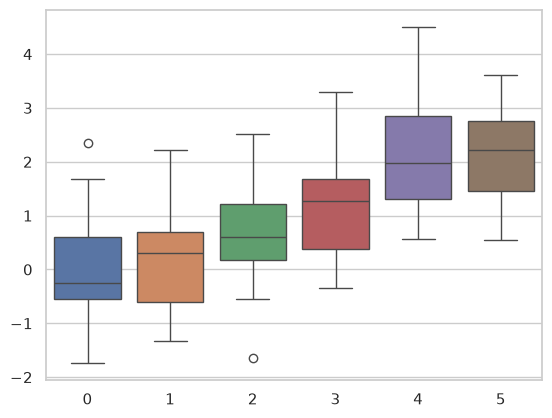

In [5]:
sns.set_style("whitegrid")
data = np.random.normal(size=(20, 6)) + np.arange(6) / 2   # 6 columns, each shifted up a bit
sns.boxplot(data=data);

Often (e.g. in talks, where you want an impression of the pattern) the grid isn't needed:

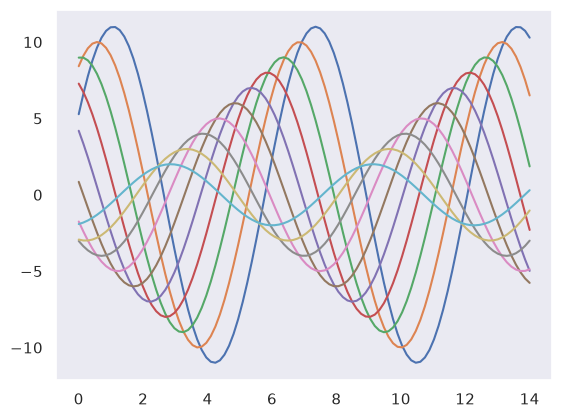

In [6]:
sns.set_style("dark")
sinplot()

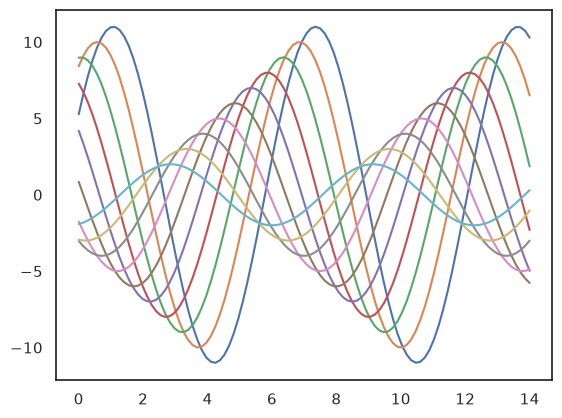

In [7]:
sns.set_style("white")
sinplot()

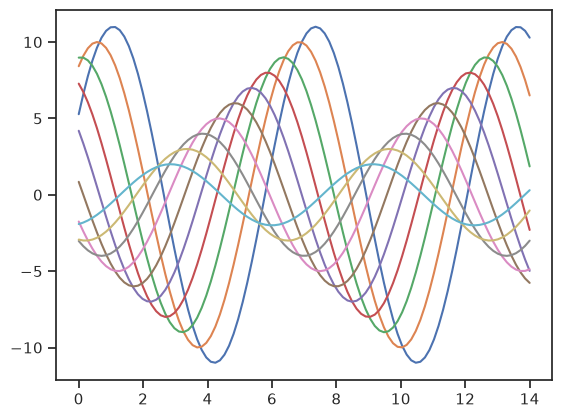

In [8]:
# ticks: a little extra structure
sns.set_style("ticks")
sinplot()

## Removing axes spines

`white` and `ticks` look better without the top and right spines. `sns.despine()` removes them:

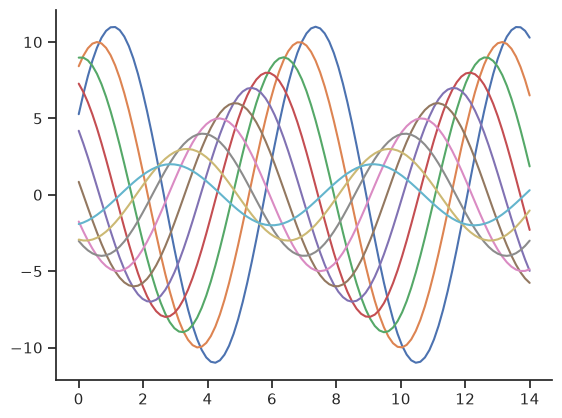

In [9]:
sinplot()
sns.despine()

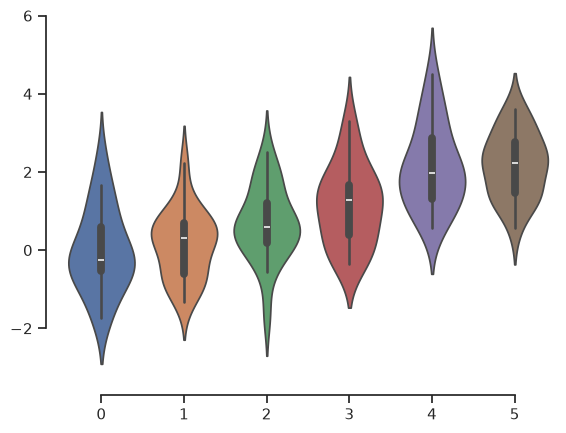

In [10]:
# offset: move spines away from the data; trim: limit spines to the tick range
f, ax = plt.subplots()
sns.violinplot(data=data)
sns.despine(offset=10, trim=True);

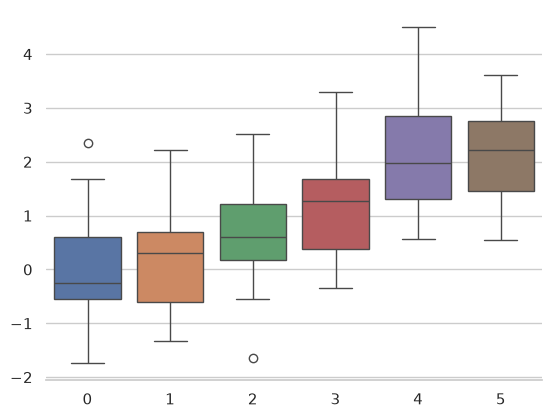

In [11]:
# Choose which spines to remove
sns.set_style("whitegrid")
sns.boxplot(data=data, palette="deep")
sns.despine(left=True)   # remove the left spine too

## Temporarily setting figure style

`axes_style()` in a **`with`** block applies a style only inside it, so one figure can mix styles:

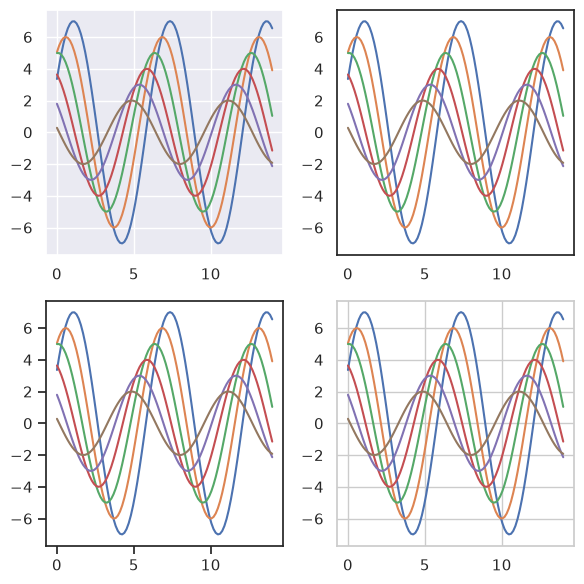

In [12]:
f = plt.figure(figsize=(6, 6))
gs = f.add_gridspec(2, 2)

with sns.axes_style("darkgrid"):
    ax = f.add_subplot(gs[0, 0])
    sinplot(6)

with sns.axes_style("white"):
    ax = f.add_subplot(gs[0, 1])
    sinplot(6)

with sns.axes_style("ticks"):
    ax = f.add_subplot(gs[1, 0])
    sinplot(6)

with sns.axes_style("whitegrid"):
    ax = f.add_subplot(gs[1, 1])
    sinplot(6)

f.tight_layout()

## Overriding elements of the seaborn styles

Pass a dict to `rc=` in `axes_style()` / `set_style()`. Only parameters that are part of the **style** can be overridden this way (`set_theme()` accepts **any** matplotlib parameter).
Call `axes_style()` with no arguments to see what's included:

In [13]:
sns.axes_style()

{'axes.facecolor': 'white',
 'axes.edgecolor': '.8',
 'axes.grid': True,
 'axes.axisbelow': True,
 'axes.labelcolor': '.15',
 'figure.facecolor': 'white',
 'grid.color': '.8',
 'grid.linestyle': '-',
 'text.color': '.15',
 'xtick.color': '.15',
 'ytick.color': '.15',
 'xtick.direction': 'out',
 'ytick.direction': 'out',
 'lines.solid_capstyle': <CapStyle.round: 'round'>,
 'patch.edgecolor': 'w',
 'patch.force_edgecolor': True,
 'image.cmap': 'rocket',
 'font.family': ['sans-serif'],
 'font.sans-serif': ['Arial',
  'DejaVu Sans',
  'Liberation Sans',
  'Bitstream Vera Sans',
  'sans-serif'],
 'xtick.bottom': False,
 'xtick.top': False,
 'ytick.left': False,
 'ytick.right': False,
 'axes.spines.left': True,
 'axes.spines.bottom': True,
 'axes.spines.right': True,
 'axes.spines.top': True}

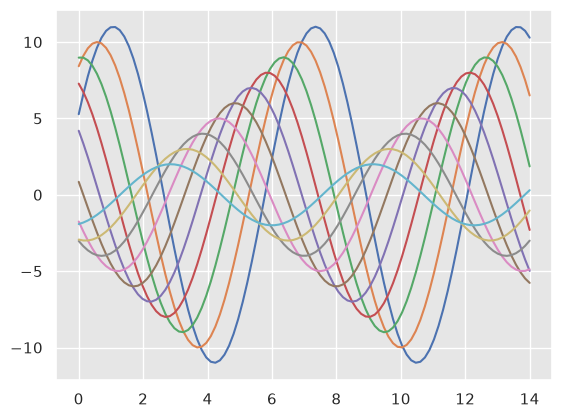

In [14]:
sns.set_style("darkgrid", {"axes.facecolor": ".9"})   # lighter grey background
sinplot()

## Scaling plot elements

The **context** scales labels, lines, etc., so the same code makes figures for different settings. Reset first:

In [15]:
sns.set_theme()

Four contexts, smallest to largest: `paper`, `notebook` (default, used above), `talk`, `poster`.

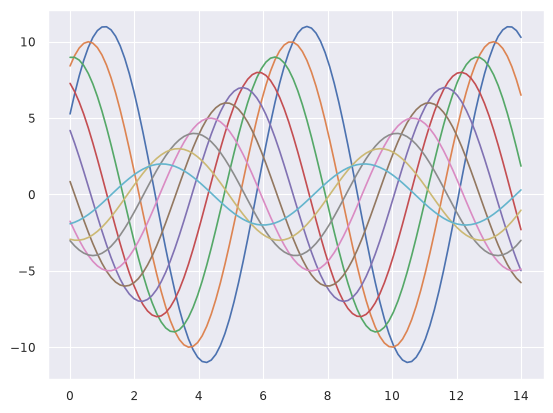

In [16]:
sns.set_context("paper")
sinplot()

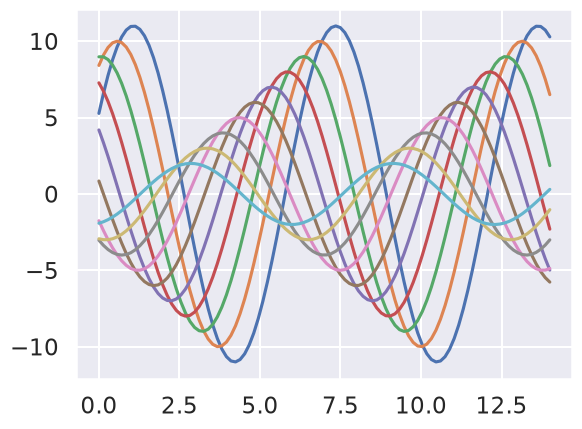

In [17]:
sns.set_context("talk")
sinplot()

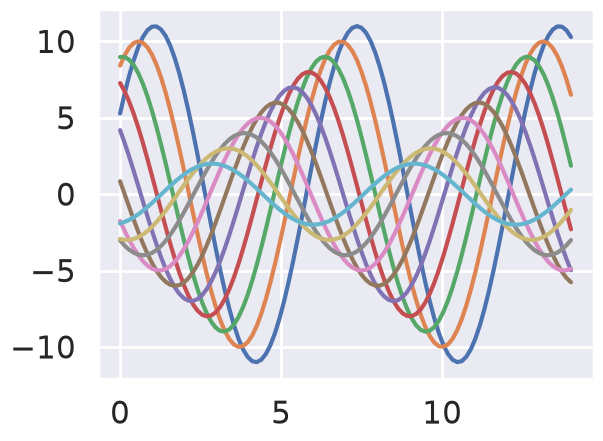

In [18]:
sns.set_context("poster")
sinplot()

Same pattern as the style functions: set by name and override with a dict. You can also scale fonts separately with `font_scale`:

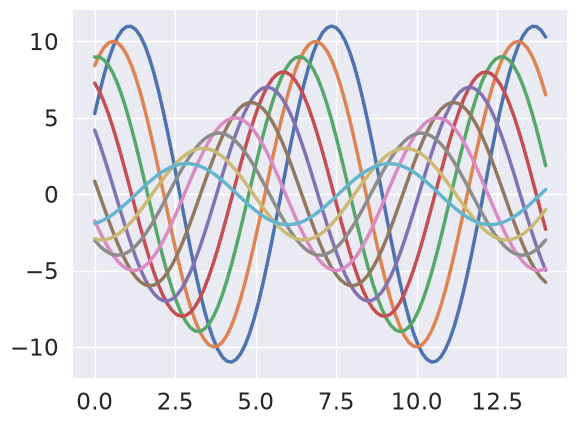

In [19]:
sns.set_context("notebook", font_scale=1.5, rc={"lines.linewidth": 2.5})
sinplot()

`plotting_context()` also works in a `with` block. Style and context (and the colour palette, next notebook) can all be set at once with `sns.set_theme(...)`.

## For `plotting_utils.py` (my addition)

A `set_style()` built from this page: ticks style, no top/right spines, a readable context, and a colour-blind-safe palette.

Text(0.5, 1.0, 'set_style(): ticks + colorblind palette, no top/right spines')

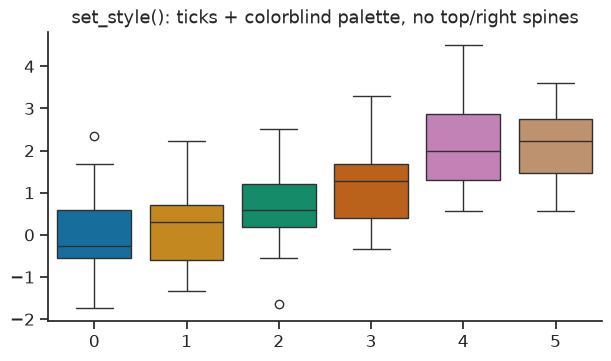

In [20]:
def set_style(context="notebook", font_scale=1.1):
    """Project-wide chart style: clean ticks, no top/right spines, colour-blind palette."""
    sns.set_theme(
        style="ticks",
        context=context,
        font_scale=font_scale,
        palette="colorblind",
        rc={"axes.spines.top": False, "axes.spines.right": False},   # despine by default
    )

set_style()
fig, ax = plt.subplots(figsize=(6, 3.5), layout="constrained")
sns.boxplot(data=data, ax=ax)
ax.set_title("set_style(): ticks + colorblind palette, no top/right spines")

In [21]:
sns.set_theme()   # reset to seaborn defaults

## Key takeaways

- `sns.set_theme()` turns on seaborn's look for **all** matplotlib plots.
- **Style** (`set_style` / `axes_style`): `darkgrid`, `whitegrid`, `dark`, `white`, `ticks`. Override with `rc={...}`.
- **Context** (`set_context` / `plotting_context`): `paper` < `notebook` < `talk` < `poster`, plus `font_scale`.
- `sns.despine(offset=, trim=, left=...)` removes spines.
- `with sns.axes_style(...)` / `with sns.plotting_context(...)` for temporary changes.